In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
d = 'enhanced_house_price_dataset.csv'
df = pd.read_csv(d)
df

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4323,1,1,2,0,23,Kolkata,Unfurnished,Yes,Yes,No,Borewell,Yes,Company,6,768553
1996,4803,4,2,1,1,8,Kolkata,Furnished,No,No,Yes,Both,No,Company,2,1117994
1997,5855,5,2,3,0,6,Kolkata,Furnished,No,Yes,No,Borewell,No,Bachelor,4,1800277
1998,2369,3,3,2,2,15,Chennai,Furnished,Yes,No,Yes,Both,Yes,Family,7,1547695


In [12]:
df.shape

(2000, 16)

In [13]:
df.isnull().any()

Area                False
Bedrooms            False
Bathrooms           False
Stories             False
Parking             False
Age                 False
City                False
Furnishing          False
Main Road           False
Guest Room          False
Basement            False
Water Supply        False
Air Conditioning    False
Preferred Tenant    False
Locality Rating     False
Price               False
dtype: bool

In [14]:
df.duplicated().any()

np.False_

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Area              2000 non-null   int64 
 1   Bedrooms          2000 non-null   int64 
 2   Bathrooms         2000 non-null   int64 
 3   Stories           2000 non-null   int64 
 4   Parking           2000 non-null   int64 
 5   Age               2000 non-null   int64 
 6   City              2000 non-null   object
 7   Furnishing        2000 non-null   object
 8   Main Road         2000 non-null   object
 9   Guest Room        2000 non-null   object
 10  Basement          2000 non-null   object
 11  Water Supply      2000 non-null   object
 12  Air Conditioning  2000 non-null   object
 13  Preferred Tenant  2000 non-null   object
 14  Locality Rating   2000 non-null   int64 
 15  Price             2000 non-null   int64 
dtypes: int64(8), object(8)
memory usage: 250.1+ KB


In [15]:
df.describe()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,3238.081000,3.031000,2.02150,1.996000,0.990500,24.008500,5.357500,1.245014e+06
std,1604.510239,1.427255,0.81263,0.811981,0.806682,14.319076,2.843015,3.001744e+05
min,401.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,3.346350e+05
25%,1860.000000,2.000000,1.00000,1.000000,0.000000,12.000000,3.000000,1.035278e+06
50%,3271.500000,3.000000,2.00000,2.000000,1.000000,24.000000,5.000000,1.246602e+06
75%,4599.750000,4.000000,3.00000,3.000000,2.000000,36.000000,8.000000,1.453607e+06
max,5996.000000,5.000000,3.00000,3.000000,2.000000,49.000000,10.000000,2.225409e+06


In [8]:
df['Price_per_Area'] = df['Price'] / df['Area']
df['Price_per_Area'].head()

0    1011.388889
1     189.092573
2     265.896374
3     179.474513
4     313.201342
Name: Price_per_Area, dtype: float64

In [9]:
city_summary = (
    df.groupby("City")
      .agg(
          Listings=("Price", "count"),
          Median_Price=("Price", "median"),
          Mean_Price=("Price", "mean"),
          Median_Area=("Area", "median"),
          Mean_Area=("Area", "mean"),
          Median_Price_per_Area=("Price_per_Area", "median"),
          Mean_Price_per_Area=("Price_per_Area", "mean"),
      )
      .sort_values("Median_Price", ascending=False)
      .reset_index()
)
city_summary

,City,Listings,Median_Price,Mean_Price,Median_Area,Mean_Area,Median_Price_per_Area,Mean_Price_per_Area
0,Mumbai,319,1297205.0,1.264457e+06,3361.0,3270.203762,384.172511,562.548087
1,Delhi,282,1258940.5,1.257933e+06,3118.5,3156.343972,400.046978,579.324462
2,Kolkata,289,1246587.0,1.252019e+06,3467.0,3392.214533,372.250154,507.708319
3,Pune,285,1243377.0,1.243350e+06,3319.0,3275.810526,366.562849,569.401501
4,Bangalore,263,1242739.0,1.237750e+06,3301.0,3251.646388,385.012241,537.960020
5,Hyderabad,304,1229773.5,1.245889e+06,3306.0,3208.263158,379.355091,571.943404
6,Chennai,258,1189014.0,1.207217e+06,3016.5,3094.678295,382.910277,548.572591


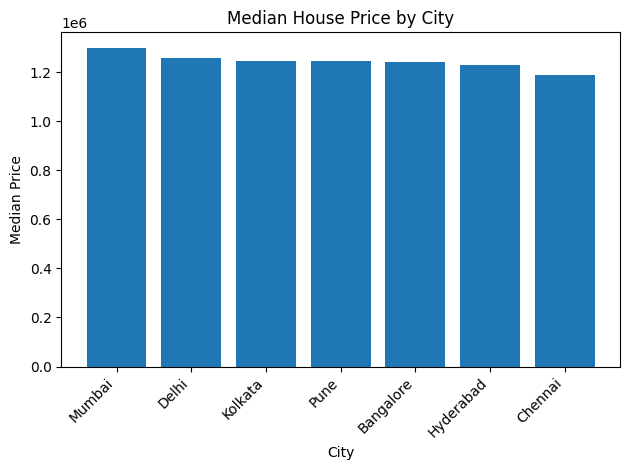

In [21]:
plt.figure()
plt.bar(city_summary["City"], city_summary["Median_Price"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("City")
plt.ylabel("Median Price")
plt.title("Median House Price by City")
plt.tight_layout()
plt.show()

In [23]:
city_rating_summary = (
    df.groupby(["City", "Locality Rating"])
      .agg(
          Listings=("Price", "count"),
          Median_Price=("Price", "median"),
          Mean_Price=("Price", "mean"),
          Median_Price_per_Area=("Price_per_Area", "median"),
      )
      .reset_index()
      .sort_values(["City", "Locality Rating"])
)
city_rating_summary.head(100)

,City,Locality Rating,Listings,Median_Price,Mean_Price,Median_Price_per_Area
0,Bangalore,1,30,1097349.5,1.132843e+06,318.426403
1,Bangalore,2,26,1085053.5,1.081280e+06,313.226009
2,Bangalore,3,28,1224921.5,1.223500e+06,364.567517
3,Bangalore,4,30,1233627.5,1.179187e+06,360.003396
4,Bangalore,5,26,1334568.5,1.336382e+06,417.672786
...,...,...,...,...,...,...
65,Pune,6,23,1272272.0,1.302841e+06,331.569055
66,Pune,7,23,1237385.0,1.276968e+06,622.730490
67,Pune,8,31,1377127.0,1.304488e+06,398.095910
68,Pune,9,34,1362237.0,1.348818e+06,323.668783


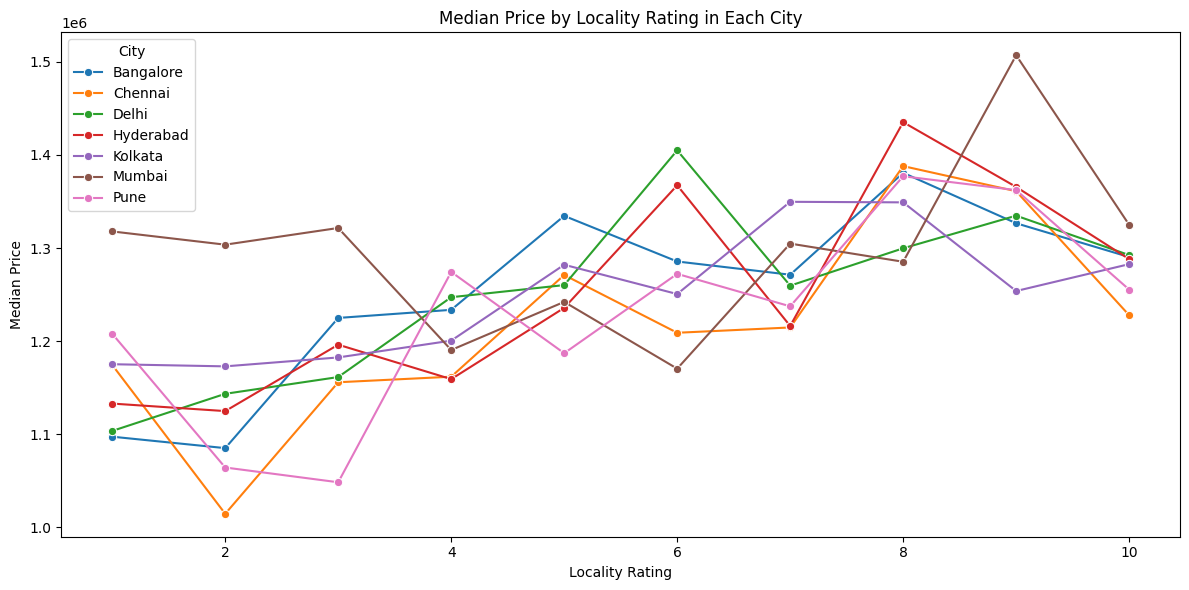

In [24]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=city_rating_summary.head(100),
    x="Locality Rating",
    y="Median_Price",
    hue="City",
    marker="o"
)
plt.title("Median Price by Locality Rating in Each City")
plt.xlabel("Locality Rating")
plt.ylabel("Median Price")
plt.tight_layout()
plt.show()


In [29]:
amenities = ["Furnishing", "Air Conditioning", "Basement", "Guest Room"]
amenity_summary_list = []
for a in amenities:
    tmp = (
        df.groupby(a)
          .agg(
              Listings=("Price", "size"),
              Median_Price=("Price", "median"),
              Mean_Price=("Price", "mean"),
              Median_Price_per_Area=("Price_per_Area", "median"),
          )
          .reset_index()
    )
    tmp.insert(0, "Amenity", a)
    amenity_summary_list.append(tmp)

amenity_summary = pd.concat(amenity_summary_list, ignore_index=True)
print("\n--- Amenity Premium (Overall) ---")
print(amenity_summary.head())


--- Amenity Premium (Overall) ---
            Amenity      Furnishing  Listings  Median_Price    Mean_Price  \
0        Furnishing       Furnished       668     1308073.5  1.318926e+06   
1        Furnishing  Semi-Furnished       696     1261360.5  1.260307e+06   
2        Furnishing     Unfurnished       636     1166698.5  1.150646e+06   
3  Air Conditioning             NaN       996     1187158.5  1.188857e+06   
4  Air Conditioning             NaN      1004     1305381.5  1.300723e+06   

   Median_Price_per_Area Air Conditioning Basement Guest Room  
0             411.333559              NaN      NaN        NaN  
1             380.897055              NaN      NaN        NaN  
2             355.074895              NaN      NaN        NaN  
3             365.945049               No      NaN        NaN  
4             398.921679              Yes      NaN        NaN  


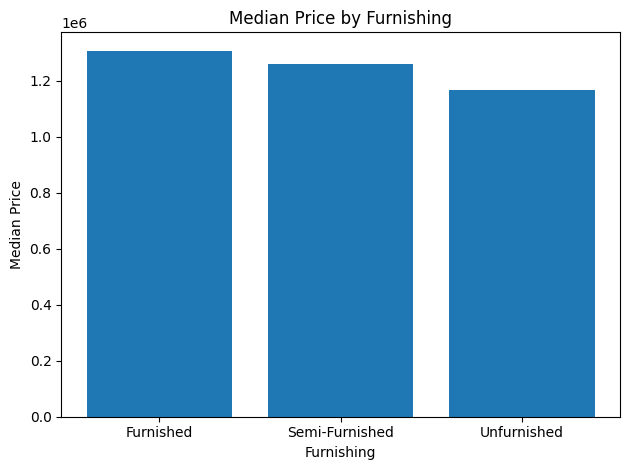

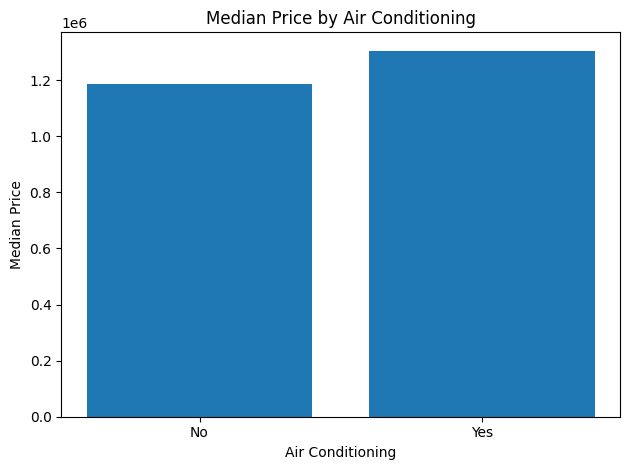

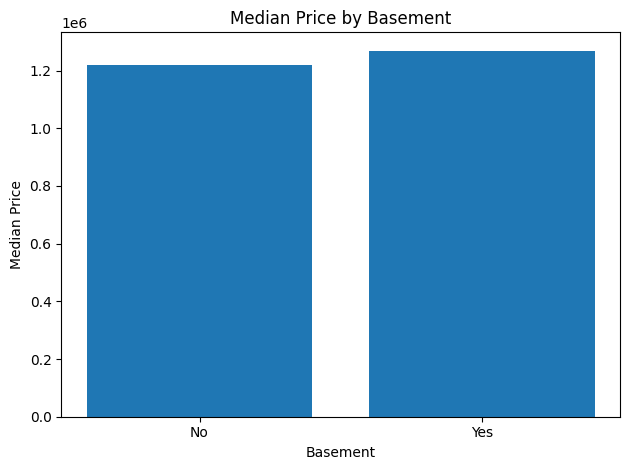

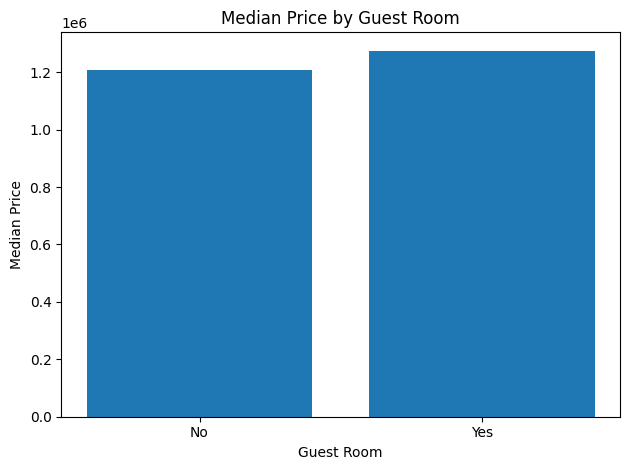

In [30]:
for a in amenities:
    tmp = amenity_summary[amenity_summary["Amenity"] == a].copy()

    plt.figure()
    plt.bar(tmp[a].astype(str), tmp["Median_Price"])
    plt.xlabel(a)
    plt.ylabel("Median Price")
    plt.title(f"Median Price by {a}")
    plt.tight_layout()
    plt.show()

In [31]:
amenity_tenant_list = []
for a in amenities:
    tmp = (
        df.groupby([a, "Preferred Tenant"])
          .agg(
              Listings=("Price", "size"),
              Median_Price=("Price", "median"),
              Mean_Price=("Price", "mean"),
              Median_Price_per_Area=("Price_per_Area", "median"),
          )
          .reset_index()
    )
    tmp.insert(0, "Amenity", a)
    amenity_tenant_list.append(tmp)

amenity_by_tenant = pd.concat(amenity_tenant_list, ignore_index=True)
print("\n--- Amenity × Preferred Tenant ---")
print(amenity_by_tenant)



--- Amenity × Preferred Tenant ---
             Amenity      Furnishing Preferred Tenant  Listings  Median_Price  \
0         Furnishing       Furnished         Bachelor       246     1311445.5   
1         Furnishing       Furnished          Company       237     1314956.0   
2         Furnishing       Furnished           Family       185     1282706.0   
3         Furnishing  Semi-Furnished         Bachelor       235     1272087.0   
4         Furnishing  Semi-Furnished          Company       229     1260771.0   
5         Furnishing  Semi-Furnished           Family       232     1258085.5   
6         Furnishing     Unfurnished         Bachelor       232     1179546.0   
7         Furnishing     Unfurnished          Company       207     1128803.0   
8         Furnishing     Unfurnished           Family       197     1190329.0   
9   Air Conditioning             NaN         Bachelor       357     1187299.0   
10  Air Conditioning             NaN          Company       332     11747

<Figure size 800x600 with 0 Axes>

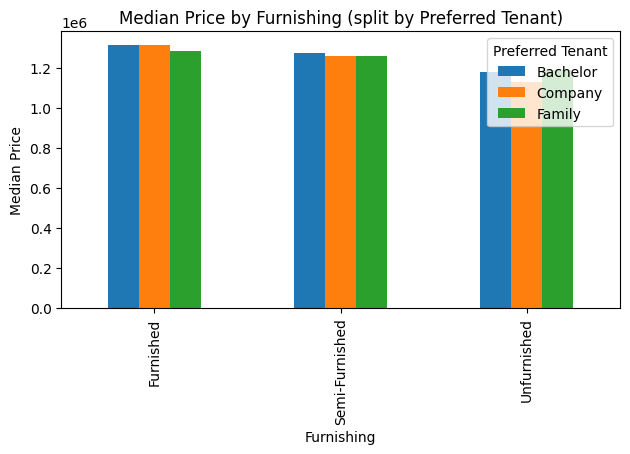

<Figure size 800x600 with 0 Axes>

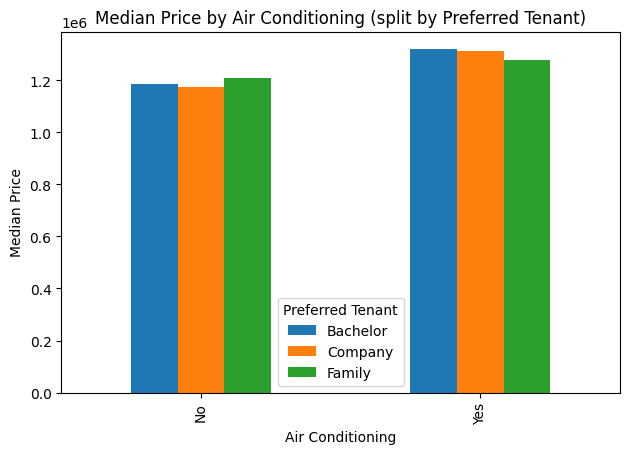

<Figure size 800x600 with 0 Axes>

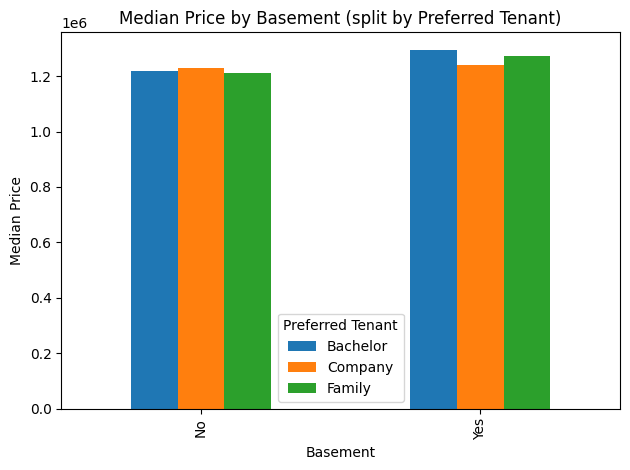

<Figure size 800x600 with 0 Axes>

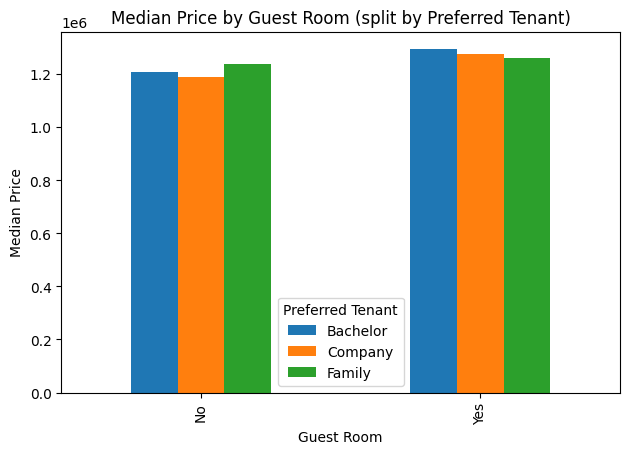

In [34]:
for a in amenities:
    tmp = amenity_by_tenant[amenity_by_tenant["Amenity"] == a].copy()

    pivot = tmp.pivot(index=a, columns="Preferred Tenant", values="Median_Price")

    plt.figure(figsize=(8, 6))
    pivot.plot(kind="bar")  # default colors
    plt.xlabel(a)
    plt.ylabel("Median Price")
    plt.title(f"Median Price by {a} (split by Preferred Tenant)")
    plt.tight_layout()
    plt.show()

In [40]:
num_cols = ["Price", "Area", "Bedrooms", "Bathrooms", "Stories", "Parking", "Age", "Locality Rating", "Price_per_Area"]
corr = df[num_cols].corr(numeric_only=True).loc['Price'].sort_values(ascending=False)

print("\n--- Correlation Matrix ---")
print(corr)


--- Correlation Matrix ---
Price              1.000000
Bedrooms           0.600588
Area               0.339137
Bathrooms          0.267506
Locality Rating    0.205792
Stories            0.205615
Parking            0.159216
Price_per_Area     0.031257
Age               -0.056614
Name: Price, dtype: float64


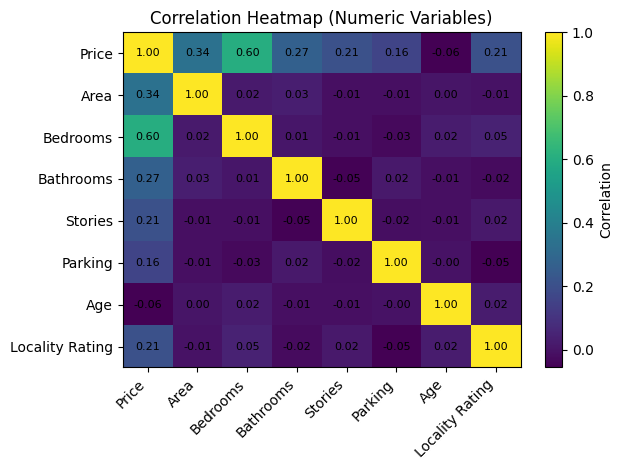

In [ ]:
num_cols = ["Price", "Area", "Bedrooms", "Bathrooms", "Stories",
            "Parking", "Age", "Locality Rating"]

corr = df[num_cols].corr(numeric_only=True)

plt.figure()
vals = corr.values.astype(float)
masked = np.ma.masked_invalid(vals)

plt.imshow(masked, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)


for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        v = vals[i, j]
        if np.isfinite(v):
            plt.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap (Numeric Variables)")
plt.tight_layout()
plt.show()

In [10]:
threshold = df["Price"].quantile(0.90)
df["Price_Segment"] = np.where(df["Price"] >= threshold, "Top 10% (Premium)", "Bottom 90%")

threshold, df["Price_Segment"].value_counts()


(np.float64(1630452.9000000001),
 Price_Segment
 Bottom 90%           1800
 Top 10% (Premium)     200
 Name: count, dtype: int64)

In [11]:
threshold = df["Price"].quantile(0.90)
df["Price_Segment"] = np.where(df["Price"] >= threshold, "Top 10% (Premium)", "Bottom 90%")

threshold, df["Price_Segment"].value_counts()
print("\n--- Price Segment Distribution ---")
print(df["Price_Segment"].value_counts())




--- Price Segment Distribution ---
Price_Segment
Bottom 90%           1800
Top 10% (Premium)     200
Name: count, dtype: int64


In [12]:
q5_num_cols = ["Price", "Area", "Bedrooms", "Bathrooms", "Stories",
               "Parking", "Age", "Locality Rating", "Price_per_Area"]

q5_numeric = df.groupby("Price_Segment")[q5_num_cols].median().reset_index()
q5_numeric


,Price_Segment,Price,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price_per_Area
0,Bottom 90%,1205149.5,3137.0,3.0,2.0,2.0,1.0,24.0,5.0,382.450333
1,Top 10% (Premium),1736365.5,4591.5,5.0,3.0,2.0,1.0,22.5,7.0,389.302252


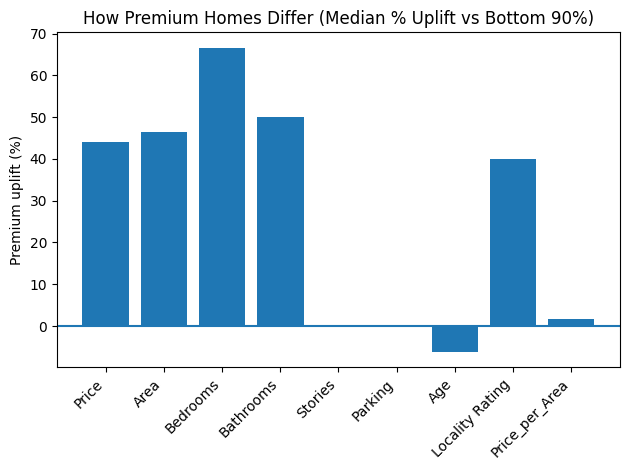

In [13]:
med = df.groupby("Price_Segment")[["Price", "Area", "Bedrooms", "Bathrooms", "Stories",
               "Parking", "Age", "Locality Rating", "Price_per_Area"]
].median()

bottom = med.loc["Bottom 90%"]
top = med.loc["Top 10% (Premium)"]

uplift_pct = ((top - bottom) / bottom) * 100
uplift_df = uplift_pct.reset_index()
uplift_df.columns = ["Variable", "Premium_vs_Bottom90_%"]

plt.figure()
plt.bar(uplift_df["Variable"], uplift_df["Premium_vs_Bottom90_%"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Premium uplift (%)")
plt.title("How Premium Homes Differ (Median % Uplift vs Bottom 90%)")
plt.axhline(0)
plt.tight_layout()
plt.show()
